In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, classification_report,
    precision_score, recall_score, f1_score, accuracy_score,
)

In [2]:
results = pd.read_csv("data/reports/classification_test_results.csv")
print(f"Loaded {len(results)} test cases")
print(f"Main category accuracy: {results['main_correct'].mean():.1%}")
print(f"Sub category accuracy:  {results['sub_correct'].mean():.1%}")

Loaded 322 test cases
Main category accuracy: 68.3%
Sub category accuracy:  45.7%


Per-category metrics helper

In [3]:
def per_category_metrics(y_true, y_pred):
    """
    Build a table with TP, FP, FN, TN, Precision, Recall, F1, Support
    for each category. Works for multi-class by treating each category
    as a one-vs-rest binary problem.
    """
    categories = sorted(set(y_true) | set(y_pred))
    rows = []

    for cat in categories:
        tp = sum((t == cat) and (p == cat) for t, p in zip(y_true, y_pred))
        fp = sum((t != cat) and (p == cat) for t, p in zip(y_true, y_pred))
        fn = sum((t == cat) and (p != cat) for t, p in zip(y_true, y_pred))
        tn = sum((t != cat) and (p != cat) for t, p in zip(y_true, y_pred))

        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
        support = tp + fn  # total true instances of this category

        rows.append({
            "Category": cat,
            "TP": tp,
            "FP": fp,
            "FN": fn,
            "TN": tn,
            "Precision": round(precision, 3),
            "Recall": round(recall, 3),
            "F1_Score": round(f1, 3),
            "Support": support,
        })

    df = pd.DataFrame(rows).sort_values("F1_Score", ascending=True).reset_index(drop=True)
    return df

Main category metrics

In [4]:
print("=" * 80)
print("  MAIN CATEGORY EVALUATION")
print("=" * 80)

y_true_main = results["nam_main_category"].tolist()
y_pred_main = results["predicted_main"].tolist()

main_metrics = per_category_metrics(y_true_main, y_pred_main)
print(main_metrics.to_string(index=False))

# summary row
print(f"\nOverall accuracy: {accuracy_score(y_true_main, y_pred_main):.1%}")
print(f"Macro avg  — Precision: {precision_score(y_true_main, y_pred_main, average='macro', zero_division=0):.3f}  "
      f"Recall: {recall_score(y_true_main, y_pred_main, average='macro', zero_division=0):.3f}  "
      f"F1: {f1_score(y_true_main, y_pred_main, average='macro', zero_division=0):.3f}")
print(f"Weighted avg — Precision: {precision_score(y_true_main, y_pred_main, average='weighted', zero_division=0):.3f}  "
      f"Recall: {recall_score(y_true_main, y_pred_main, average='weighted', zero_division=0):.3f}  "
      f"F1: {f1_score(y_true_main, y_pred_main, average='weighted', zero_division=0):.3f}")


  MAIN CATEGORY EVALUATION
            Category  TP  FP  FN  TN  Precision  Recall  F1_Score  Support
         clinical_mr   0   2   0 320      0.000   0.000     0.000        0
               other   0   5   3 314      0.000   0.000     0.000        3
          physiology   0   0   3 319      0.000   0.000     0.000        3
system_related_parts   0   1   1 320      0.000   0.000     0.000        1
    third_party_item   0   2   0 320      0.000   0.000     0.000        0
              magnet   7   9   4 302      0.438   0.636     0.519       11
    data_acquisition  19  17  17 269      0.528   0.528     0.528       36
       image_quality   2   0   3 317      1.000   0.400     0.571        5
       reconstructor   4   2   4 312      0.667   0.500     0.571        8
       environmental   9   7   5 301      0.562   0.643     0.600       14
            software  16  13   7 286      0.552   0.696     0.615       23
                coil  16  11   3 292      0.593   0.842     0.696       1

Main category confusion matrix

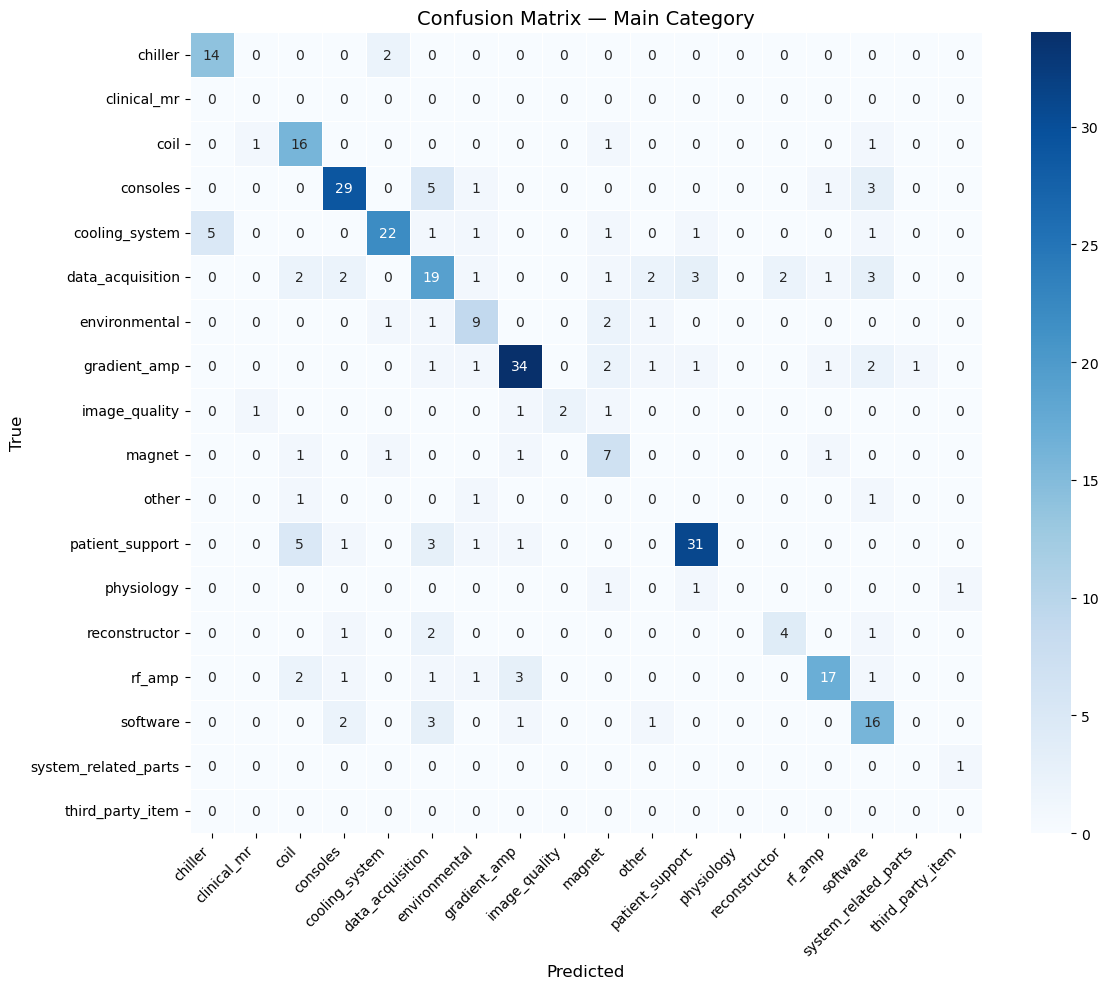

Saved: data/reports/confusion_matrix_main.png


In [5]:
main_labels = sorted(set(y_true_main) | set(y_pred_main))
cm_main = confusion_matrix(y_true_main, y_pred_main, labels=main_labels)

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    cm_main,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=main_labels,
    yticklabels=main_labels,
    linewidths=0.5,
    ax=ax,
)
ax.set_xlabel("Predicted", fontsize=12)
ax.set_ylabel("True", fontsize=12)
ax.set_title("Confusion Matrix — Main Category", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("data/reports/confusion_matrix_main.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: data/reports/confusion_matrix_main.png")

Main category normalized confusion matrix (percentages)

C:\Users\320305732\AppData\Local\Temp\ipykernel_5260\3772959756.py:1: RuntimeWarning: invalid value encountered in divide
  cm_main_norm = cm_main.astype(float) / cm_main.sum(axis=1, keepdims=True)


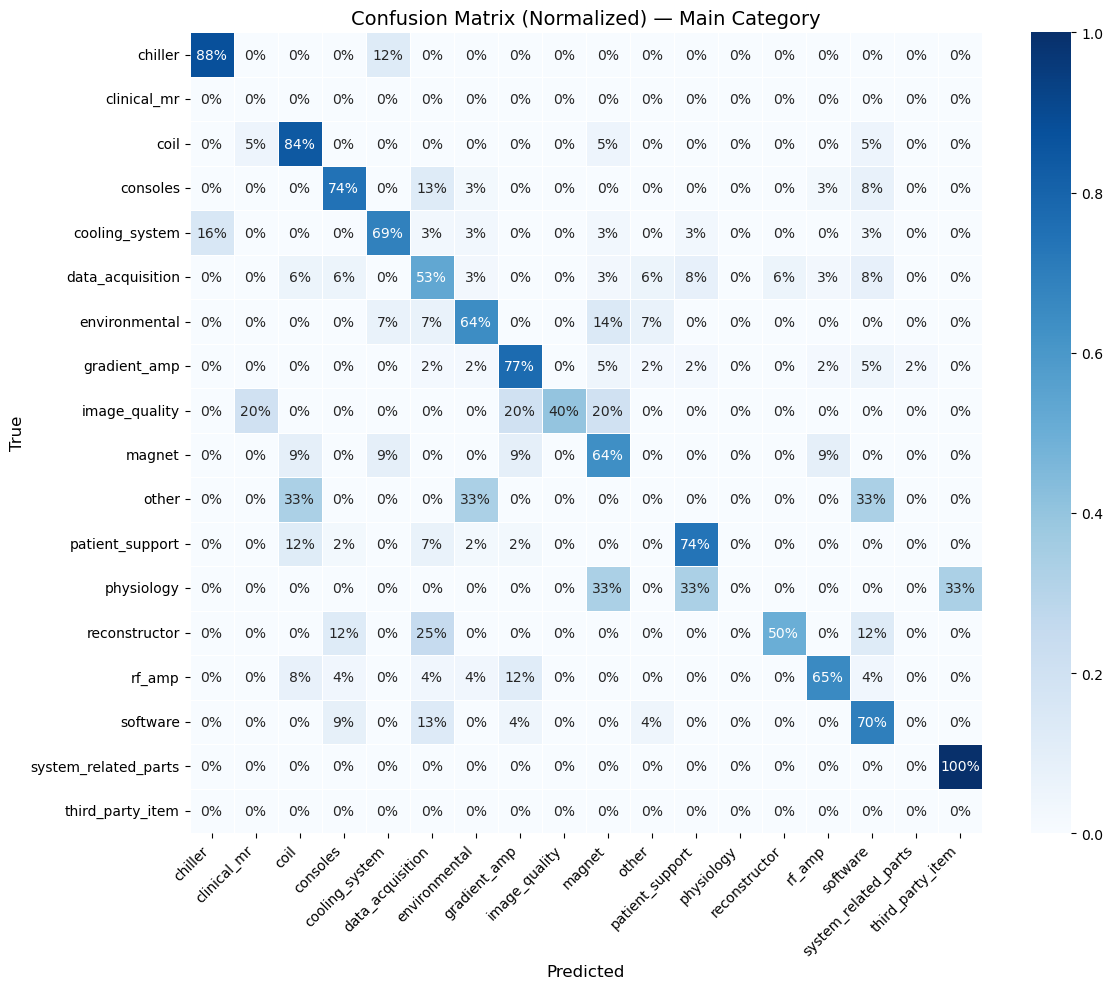

Saved: data/reports/confusion_matrix_main_normalized.png


In [6]:
cm_main_norm = cm_main.astype(float) / cm_main.sum(axis=1, keepdims=True)
cm_main_norm = np.nan_to_num(cm_main_norm)  # handle categories with 0 support

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    cm_main_norm,
    annot=True,
    fmt=".0%",
    cmap="Blues",
    xticklabels=main_labels,
    yticklabels=main_labels,
    linewidths=0.5,
    vmin=0,
    vmax=1,
    ax=ax,
)
ax.set_xlabel("Predicted", fontsize=12)
ax.set_ylabel("True", fontsize=12)
ax.set_title("Confusion Matrix (Normalized) — Main Category", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("data/reports/confusion_matrix_main_normalized.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: data/reports/confusion_matrix_main_normalized.png")


Sub category metrics

In [8]:
print(results[results["nam_sub_category"].isna()])

                  extracted_problem_description_remote nam_main_category  \
180  Monitor went completely black while running a ...            rf_amp   
230             NO PRS - HOST PC not on after shutdown     reconstructor   

    nam_sub_category predicted_main  predicted_sub  main_correct  sub_correct  
180              NaN       consoles  mon_mouse_key         False        False  
230              NaN       consoles     host_recon         False        False  


In [9]:
print(results[results["predicted_sub"].isna()])

Empty DataFrame
Columns: [extracted_problem_description_remote, nam_main_category, nam_sub_category, predicted_main, predicted_sub, main_correct, sub_correct]
Index: []


cleaning step

In [12]:
# drop rows where either true or predicted sub category is missing
sub_valid = results.dropna(subset=["nam_sub_category", "predicted_sub"])
print(f"Sub category evaluation: {len(sub_valid)}/{len(results)} cases "
      f"({len(results) - len(sub_valid)} dropped due to missing values)")

Sub category evaluation: 320/322 cases (2 dropped due to missing values)


In [13]:
print("=" * 80)
print("  SUB CATEGORY EVALUATION")
print("=" * 80)

y_true_sub = sub_valid["nam_sub_category"].tolist()
y_pred_sub = sub_valid["predicted_sub"].tolist()

sub_metrics = per_category_metrics(y_true_sub, y_pred_sub)
print(sub_metrics.to_string(index=False))

print(f"\nOverall accuracy: {accuracy_score(y_true_sub, y_pred_sub):.1%}")
print(f"Macro avg  — Precision: {precision_score(y_true_sub, y_pred_sub, average='macro', zero_division=0):.3f}  "
      f"Recall: {recall_score(y_true_sub, y_pred_sub, average='macro', zero_division=0):.3f}  "
      f"F1: {f1_score(y_true_sub, y_pred_sub, average='macro', zero_division=0):.3f}")
print(f"Weighted avg — Precision: {precision_score(y_true_sub, y_pred_sub, average='weighted', zero_division=0):.3f}  "
      f"Recall: {recall_score(y_true_sub, y_pred_sub, average='weighted', zero_division=0):.3f}  "
      f"F1: {f1_score(y_true_sub, y_pred_sub, average='weighted', zero_division=0):.3f}")

  SUB CATEGORY EVALUATION
                    Category  TP  FP  FN  TN  Precision  Recall  F1_Score  Support
                         acr   0   0   1 319      0.000   0.000     0.000        1
          analog_non_synergy   0   0   1 319      0.000   0.000     0.000        1
                 backend_box   0   0   3 317      0.000   0.000     0.000        3
                   artifacts   0   1   0 319      0.000   0.000     0.000        0
                    coldhead   0   0   1 319      0.000   0.000     0.000        1
                  controller   0   0   3 317      0.000   0.000     0.000        3
                    bodycoil   0   1   1 318      0.000   0.000     0.000        1
            data_acquisition   0   1   0 319      0.000   0.000     0.000        0
               driver_module   0   0   2 318      0.000   0.000     0.000        2
                 exhaust_fan   0   1   0 319      0.000   0.000     0.000        0
                   fse_aware   0   8   4 308      0.000   0.0

Sub category confusion matrix

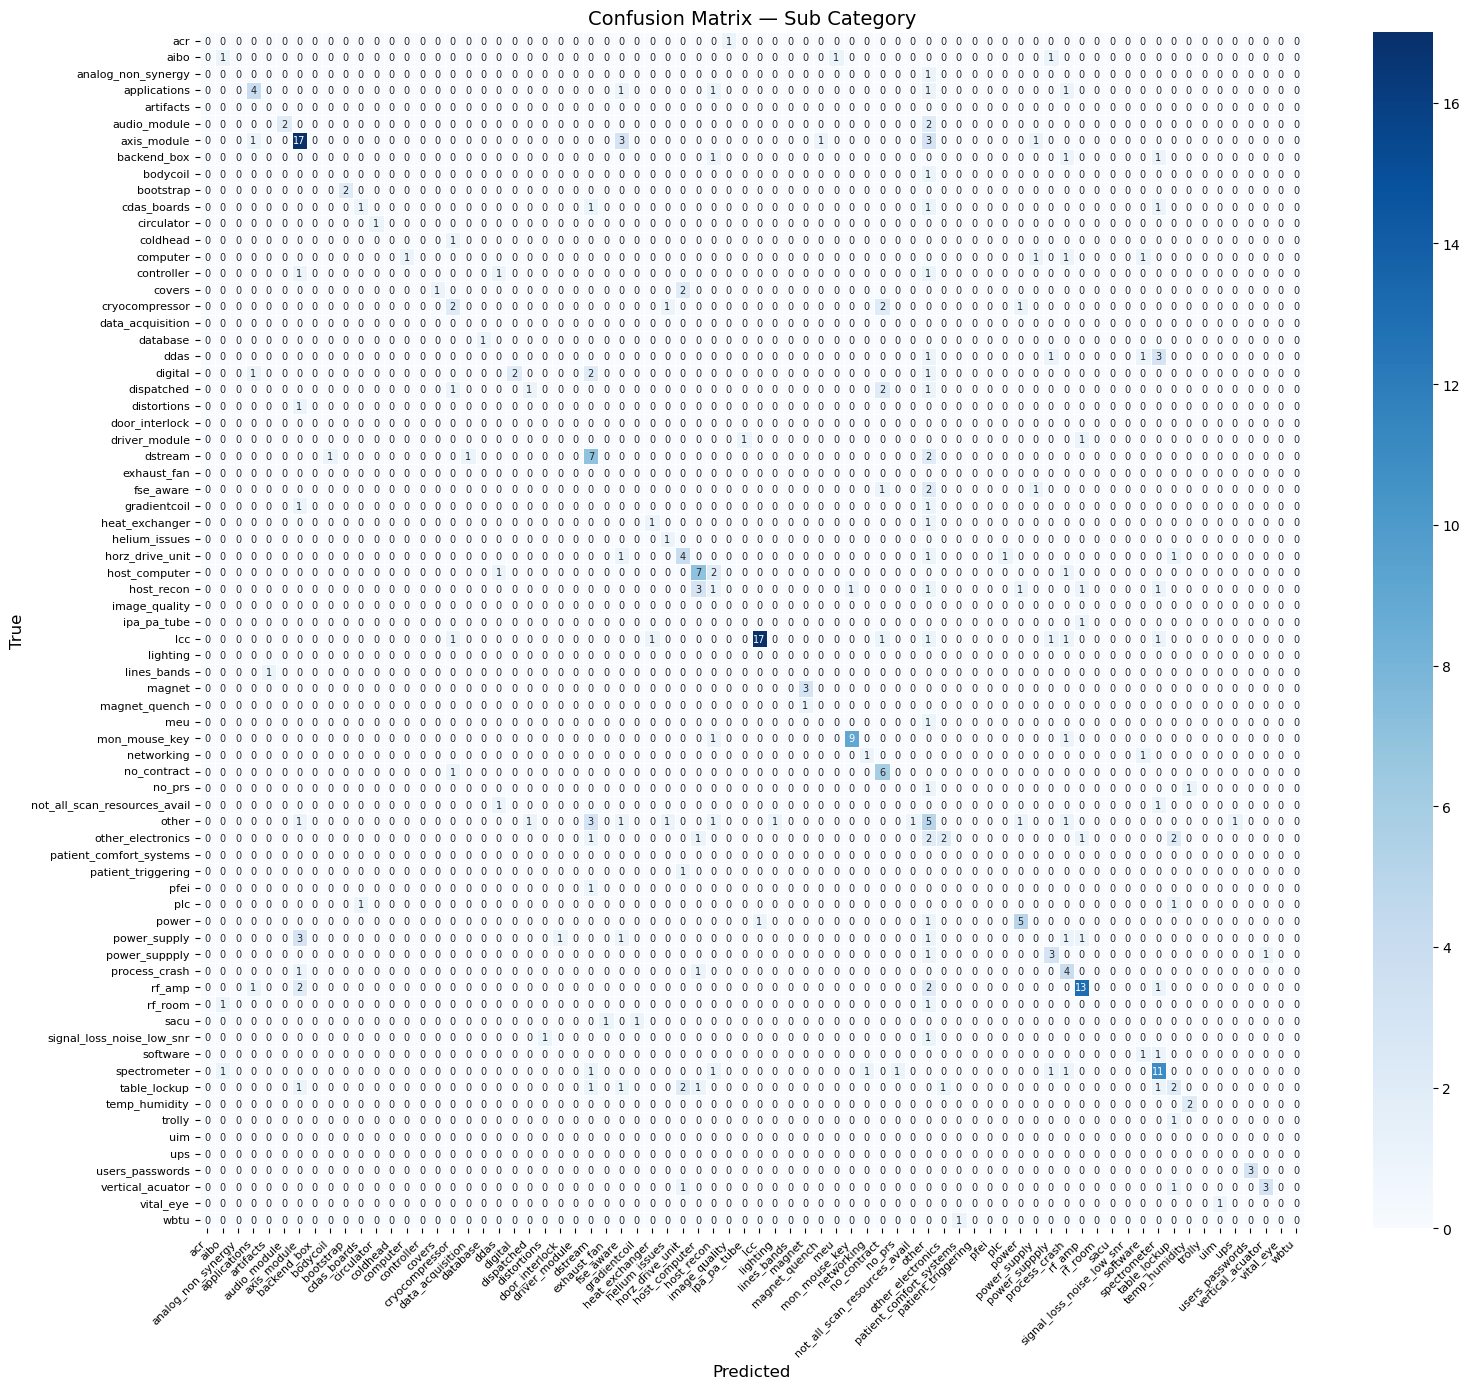

Saved: data/reports/confusion_matrix_sub.png


In [14]:
sub_labels = sorted(set(y_true_sub) | set(y_pred_sub))
cm_sub = confusion_matrix(y_true_sub, y_pred_sub, labels=sub_labels)

fig, ax = plt.subplots(figsize=(16, 14))
sns.heatmap(
    cm_sub,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=sub_labels,
    yticklabels=sub_labels,
    linewidths=0.5,
    annot_kws={"size": 7},
    ax=ax,
)
ax.set_xlabel("Predicted", fontsize=12)
ax.set_ylabel("True", fontsize=12)
ax.set_title("Confusion Matrix — Sub Category", fontsize=14)
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig("data/reports/confusion_matrix_sub.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: data/reports/confusion_matrix_sub.png")

Sub category normalized confusion matrix

C:\Users\320305732\AppData\Local\Temp\ipykernel_5260\1933232047.py:1: RuntimeWarning: invalid value encountered in divide
  cm_sub_norm = cm_sub.astype(float) / cm_sub.sum(axis=1, keepdims=True)


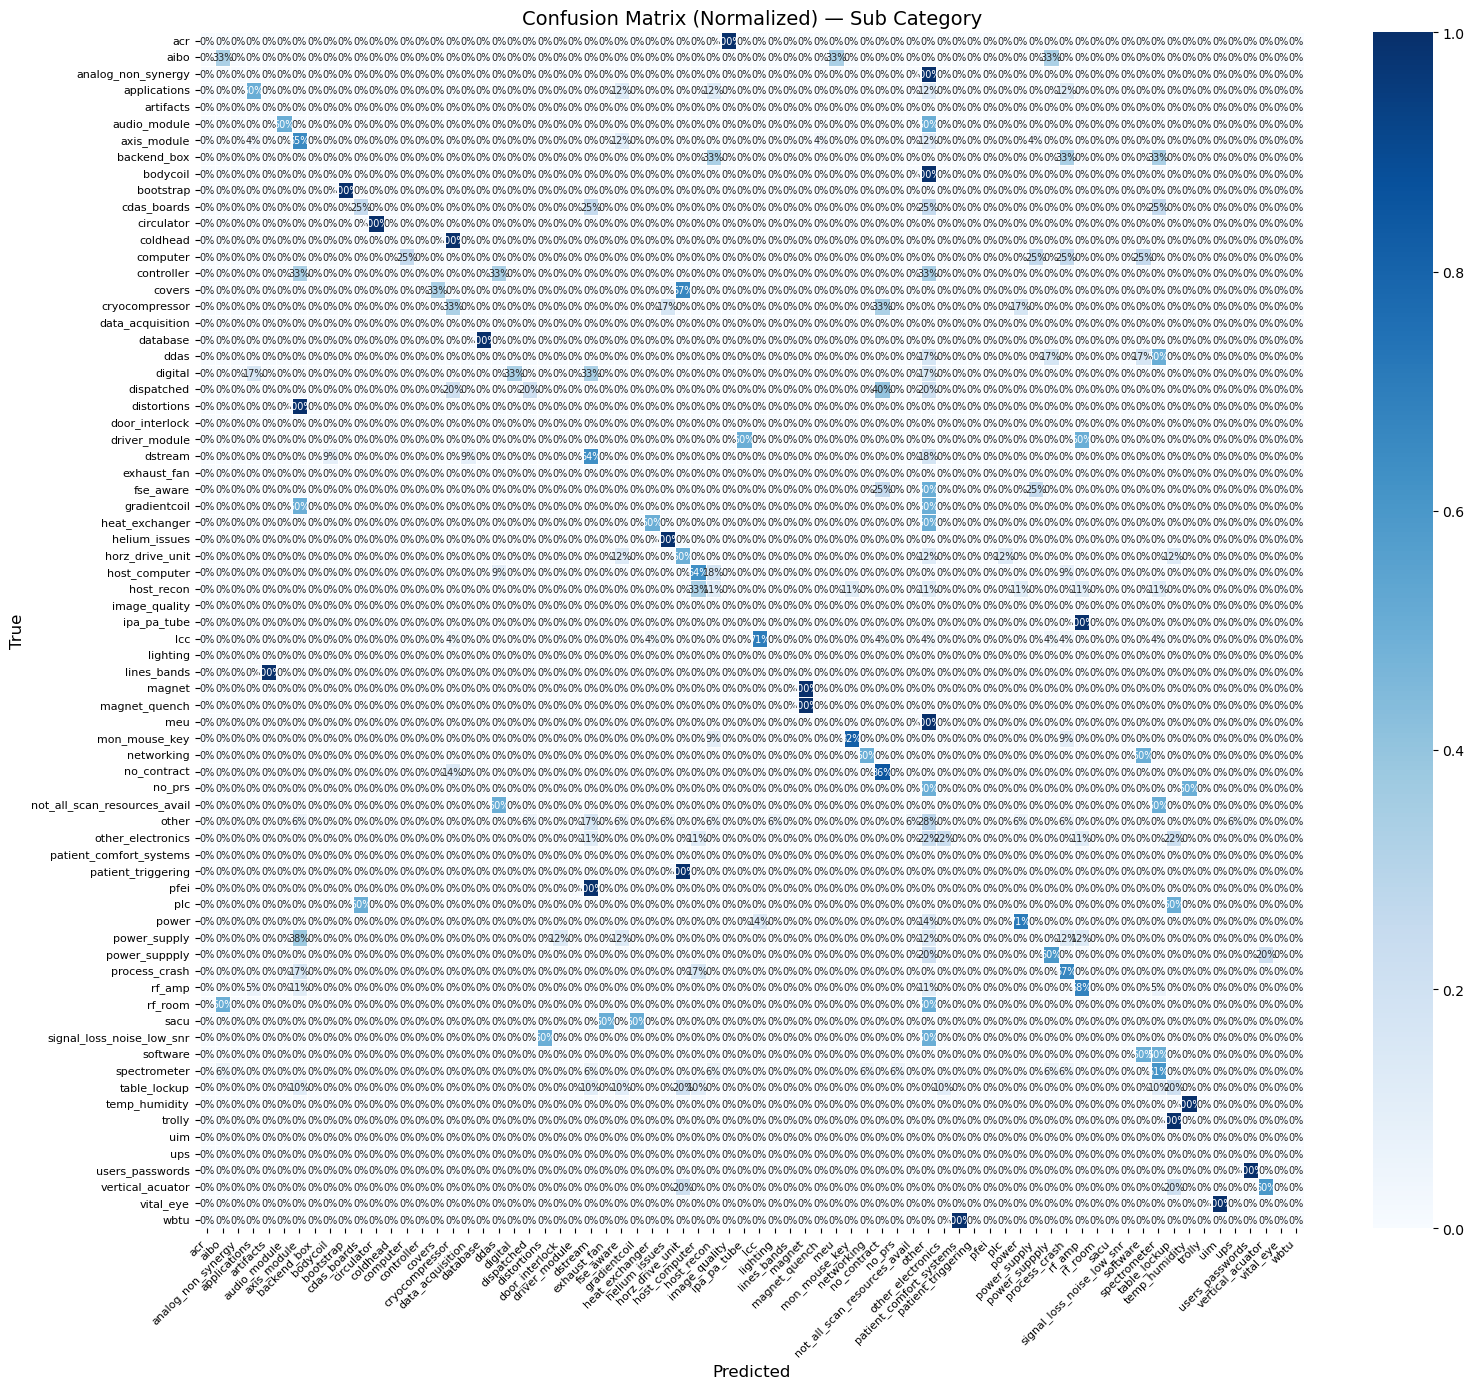

Saved: data/reports/confusion_matrix_sub_normalized.png


In [15]:
cm_sub_norm = cm_sub.astype(float) / cm_sub.sum(axis=1, keepdims=True)
cm_sub_norm = np.nan_to_num(cm_sub_norm)

fig, ax = plt.subplots(figsize=(16, 14))
sns.heatmap(
    cm_sub_norm,
    annot=True,
    fmt=".0%",
    cmap="Blues",
    xticklabels=sub_labels,
    yticklabels=sub_labels,
    linewidths=0.5,
    annot_kws={"size": 7},
    vmin=0,
    vmax=1,
    ax=ax,
)
ax.set_xlabel("Predicted", fontsize=12)
ax.set_ylabel("True", fontsize=12)
ax.set_title("Confusion Matrix (Normalized) — Sub Category", fontsize=14)
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig("data/reports/confusion_matrix_sub_normalized.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: data/reports/confusion_matrix_sub_normalized.png")


Top confusion pairs (most frequent mistakes)

In [16]:
print("=" * 80)
print("  TOP CONFUSION PAIRS — MAIN CATEGORY")
print("=" * 80)

mistakes_main = results[~results["main_correct"]]
if len(mistakes_main) > 0:
    confusion_pairs = (
        mistakes_main
        .groupby(["nam_main_category", "predicted_main"])
        .size()
        .reset_index(name="count")
        .sort_values("count", ascending=False)
        .head(15)
    )
    confusion_pairs.columns = ["True", "Predicted", "Count"]
    print(confusion_pairs.to_string(index=False))
else:
    print("No misclassifications!")

print(f"\n{'=' * 80}")
print("  TOP CONFUSION PAIRS — SUB CATEGORY")
print("=" * 80)

mistakes_sub = results[~results["sub_correct"]]
if len(mistakes_sub) > 0:
    confusion_pairs_sub = (
        mistakes_sub
        .groupby(["nam_sub_category", "predicted_sub"])
        .size()
        .reset_index(name="count")
        .sort_values("count", ascending=False)
        .head(15)
    )
    confusion_pairs_sub.columns = ["True", "Predicted", "Count"]
    print(confusion_pairs_sub.to_string(index=False))
else:
    print("No misclassifications!")

  TOP CONFUSION PAIRS — MAIN CATEGORY
            True        Predicted  Count
 patient_support             coil      5
  cooling_system          chiller      5
        consoles data_acquisition      5
        software data_acquisition      3
          rf_amp     gradient_amp      3
 patient_support data_acquisition      3
        consoles         software      3
data_acquisition         software      3
data_acquisition  patient_support      3
         chiller   cooling_system      2
        software         consoles      2
   reconstructor data_acquisition      2
data_acquisition    reconstructor      2
    gradient_amp           magnet      2
    gradient_amp         software      2

  TOP CONFUSION PAIRS — SUB CATEGORY
             True       Predicted  Count
      axis_module           other      3
      axis_module       fse_aware      3
       host_recon   host_computer      3
             ddas    spectrometer      3
            other         dstream      3
     power_supply     

Save metrics tables to CSV

In [ ]:
main_metrics.to_csv("data/reports/main_category_metrics.csv", index=False)
sub_metrics.to_csv("data/reports/sub_category_metrics.csv", index=False)
print("Saved: data/reports/main_category_metrics.csv")
print("Saved: data/reports/sub_category_metrics.csv")